# BANC Connections Dataset — Visualization

Exploratory visualization of `connections_princeton.csv.gz` (~3.78 M synaptic connections).

**Columns:** `pre_root_id`, `post_root_id`, `neuropil`, `syn_count`, `nt_type`

**Topics:**
1. Data overview & missing values
2. Neuropil region distribution (top-30)
3. Synapse count distribution
4. NT type distribution
5. Top hub neurons (upstream / downstream)
6. Degree distributions (log-log)
7. Heatmap: neuropil x NT type
8. Per-neuropil total synapse count

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from banc_utils import (
    load_connections,
    connection_neuropil_counts,
    connection_syn_count_stats,
    connection_nt_type_counts,
    top_upstream_neurons,
    top_downstream_neurons,
    syn_count_per_neuropil_nt,
    degree_distribution,
    missing_data_summary,
    plot_bar, plot_barh, plot_histogram, plot_heatmap, plot_degree_distribution,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

conn_df = load_connections()
print(f'Loaded: {conn_df.shape[0]:,} rows x {conn_df.shape[1]} columns')
conn_df.head(3)

Loaded: 3,777,046 rows x 5 columns


,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575941350274352,720575941399414563,VNC_T1_ProNm_R,28,NaN
1,720575941350274352,720575941399414563,VNC_unassigned_R,2,NaN
2,720575941350274352,720575941409918831,VNC_T1_ProNm_R,3,NaN


## 1. Data Overview & Missing Values

Shape: (3777046, 5)

Dtypes:
pre_root_id       int64
post_root_id      int64
neuropil         object
syn_count         int64
nt_type         float64
dtype: object

Stats:


,pre_root_id,post_root_id,syn_count,nt_type
count,3.777046e+06,3.777046e+06,3.777046e+06,0.0
mean,7.205759e+17,7.205759e+17,5.889076e+00,NaN
std,7.385727e+07,7.379714e+07,9.982205e+00,NaN
min,7.205759e+17,7.205759e+17,1.000000e+00,NaN
25%,7.205759e+17,7.205759e+17,2.000000e+00,NaN
50%,7.205759e+17,7.205759e+17,3.000000e+00,NaN
75%,7.205759e+17,7.205759e+17,6.000000e+00,NaN
max,7.205759e+17,7.205759e+17,9.220000e+02,NaN



Missing values:


,missing_count,missing_pct
nt_type,3777046,100.0
pre_root_id,0,0.0
post_root_id,0,0.0
neuropil,0,0.0
syn_count,0,0.0


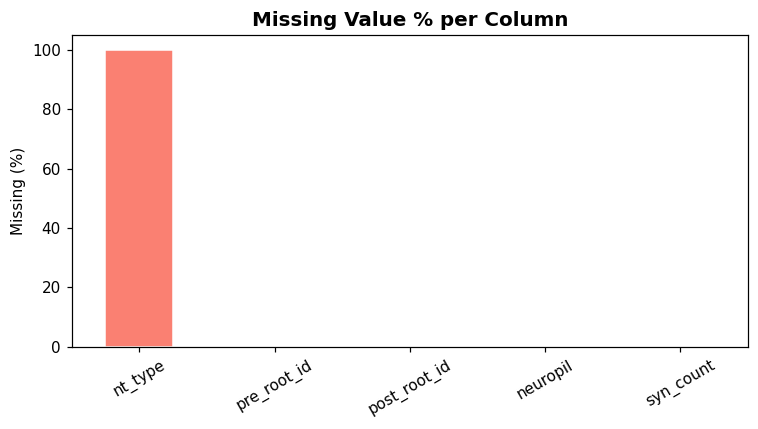

In [2]:
print('Shape:', conn_df.shape)
print('\nDtypes:')
print(conn_df.dtypes)
print('\nStats:')
display(conn_df.describe())

miss = missing_data_summary(conn_df)
print('\nMissing values:')
display(miss)

fig, ax = plt.subplots(figsize=(7, 4))
miss['missing_pct'].plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Value % per Column', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 2. Neuropil Region Distribution (Top 30)

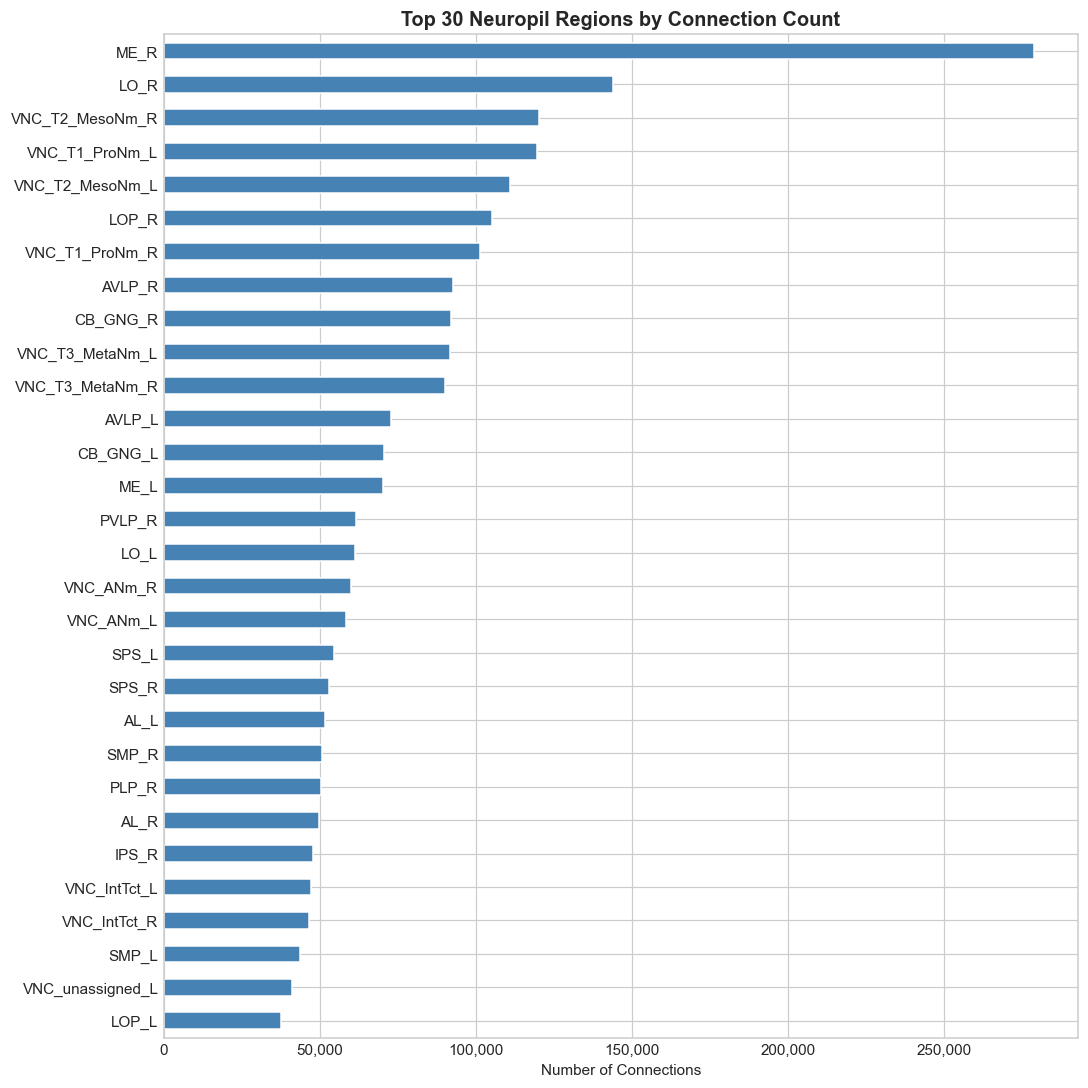

In [3]:
neuropil_counts = connection_neuropil_counts(conn_df, top_n=30)
plot_barh(neuropil_counts, title='Top 30 Neuropil Regions by Connection Count',
          xlabel='Number of Connections', figsize=(10, 10))
plt.show()

## 3. Synapse Count Distribution

count    3.777046e+06
mean     5.889076e+00
std      9.982205e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      9.220000e+02
Name: syn_count, dtype: float64


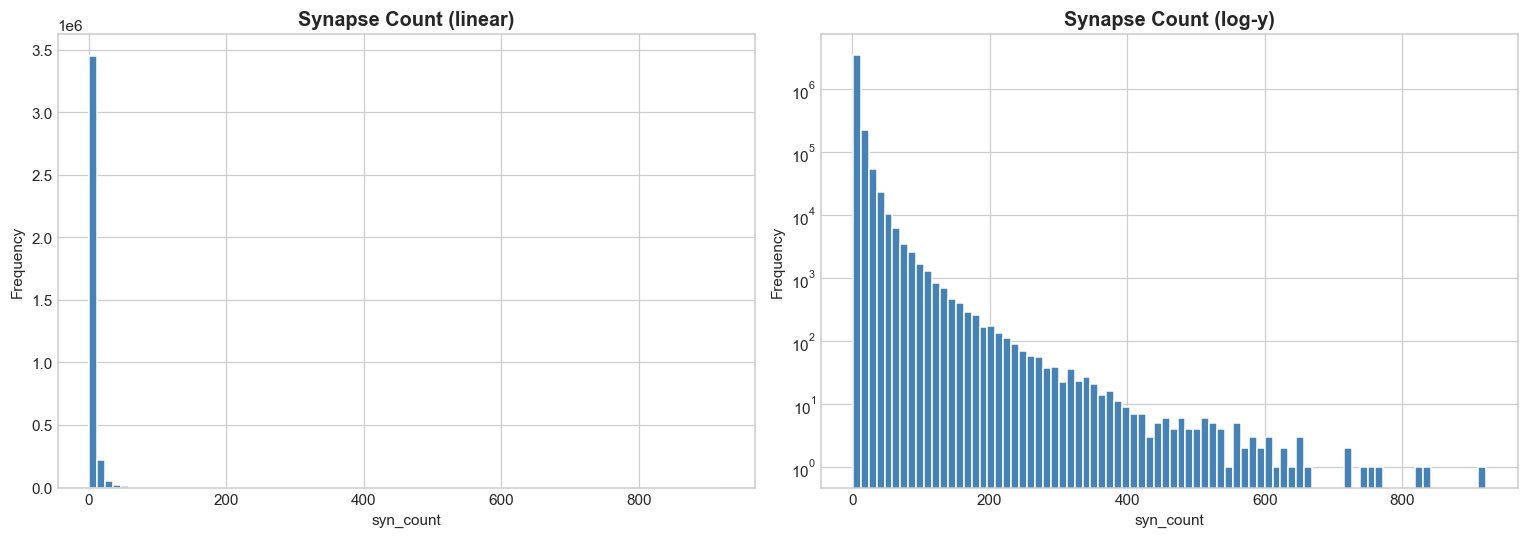

In [4]:
print(connection_syn_count_stats(conn_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_histogram(conn_df['syn_count'], title='Synapse Count (linear)',
               xlabel='syn_count', bins=80, ax=axes[0])
plot_histogram(conn_df['syn_count'], title='Synapse Count (log-y)',
               xlabel='syn_count', bins=80, log_scale=True, ax=axes[1])
plt.tight_layout(); plt.show()

## 4. NT Type Distribution in Connections

nt_type
(missing)    3777046
Name: count, dtype: int64


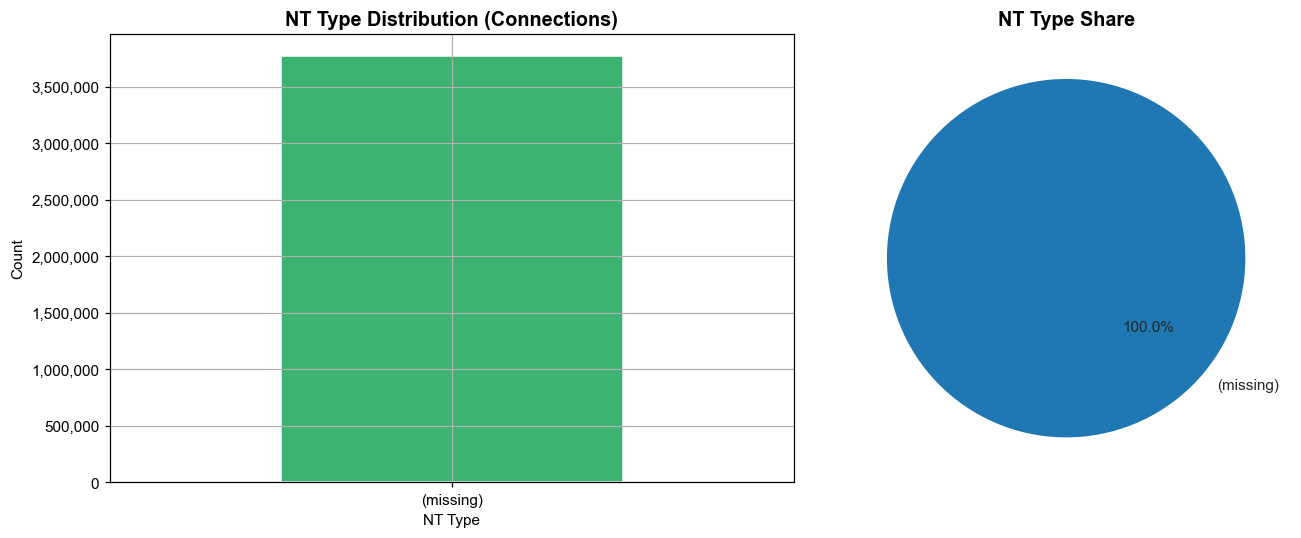

In [3]:
nt_counts = connection_nt_type_counts(conn_df)
print(nt_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar(nt_counts, title='NT Type Distribution (Connections)',
         xlabel='NT Type', color='mediumseagreen', rotate_xticks=0, ax=axes[0])
axes[1].pie(nt_counts.values, labels=nt_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('NT Type Share', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Top Hub Neurons (Upstream & Downstream)

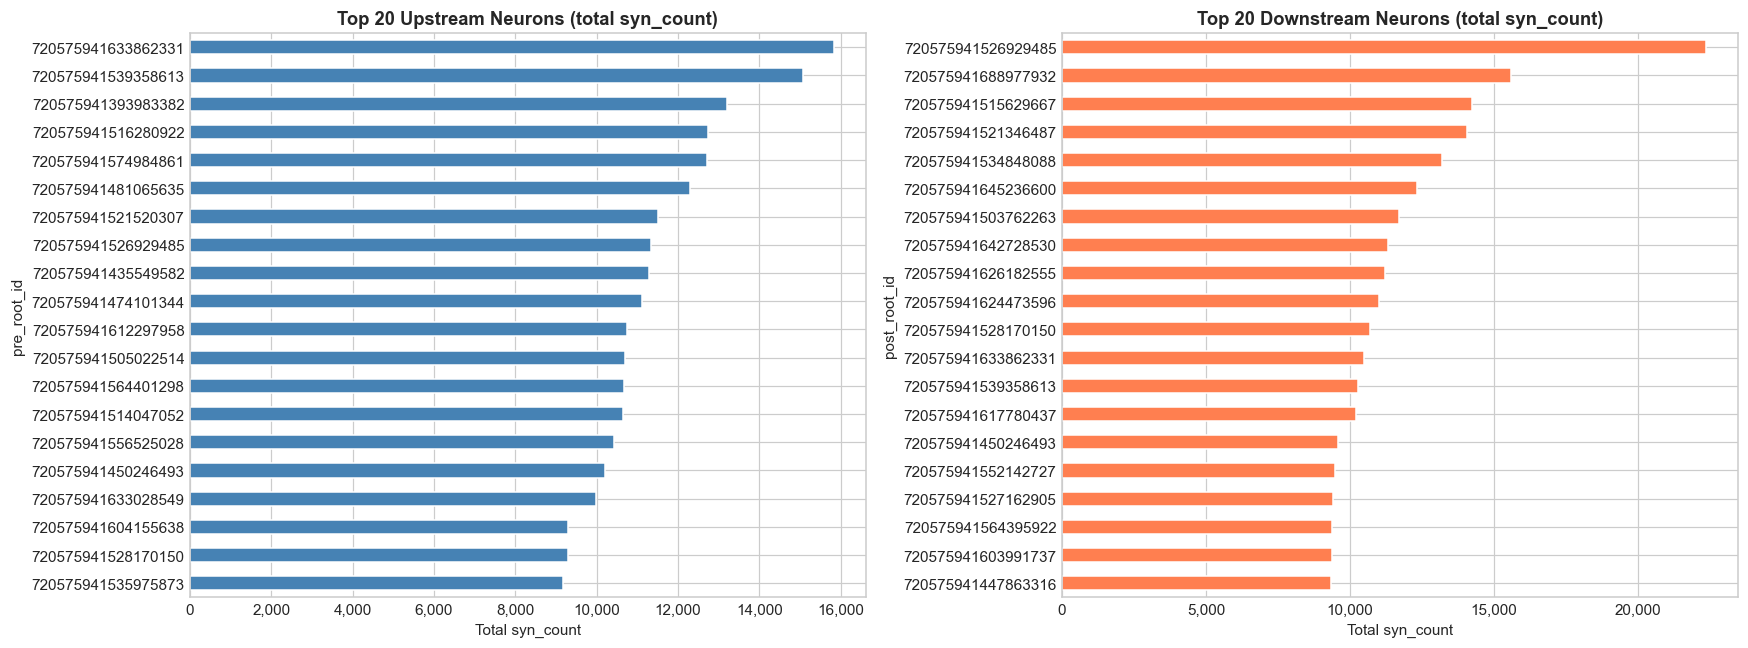

In [4]:
top_pre  = top_upstream_neurons(conn_df, top_n=20)
top_post = top_downstream_neurons(conn_df, top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_pre.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Upstream Neurons (total syn_count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total syn_count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

top_post.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 20 Downstream Neurons (total syn_count)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total syn_count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

## 6. Degree Distributions (log-log)

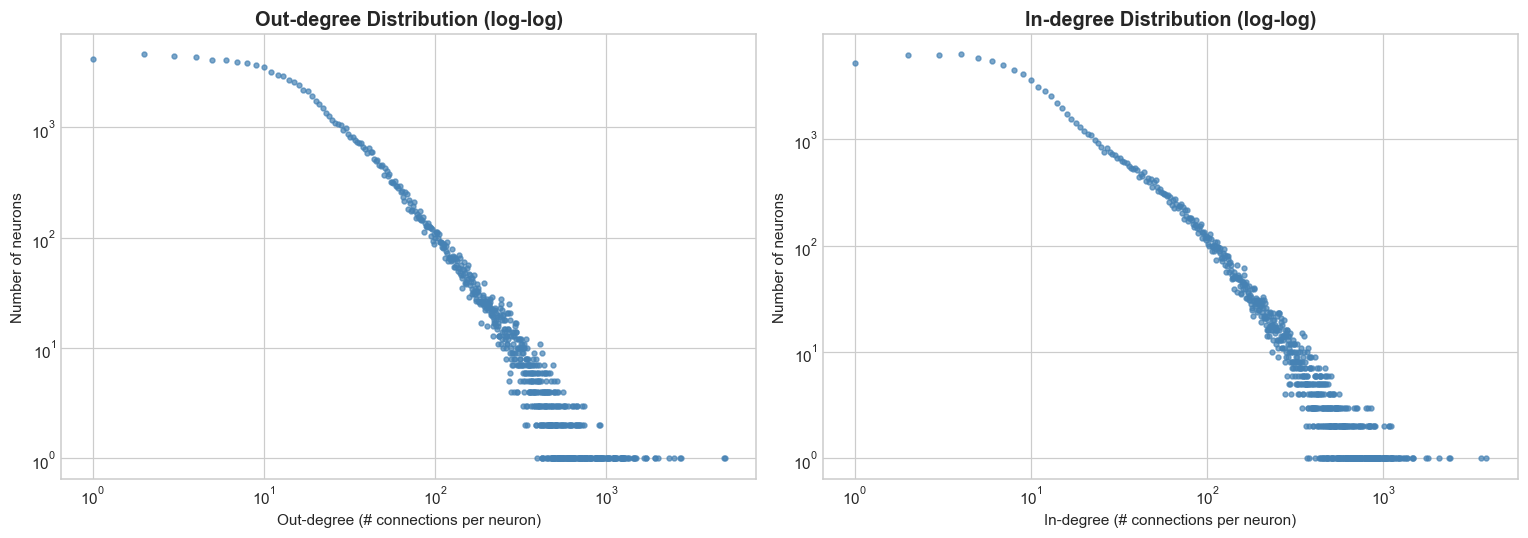

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_degree_distribution(conn_df, kind='out', log_log=True, ax=axes[0])
plot_degree_distribution(conn_df, kind='in',  log_log=True, ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Heatmap: Top-20 Neuropils x NT Type

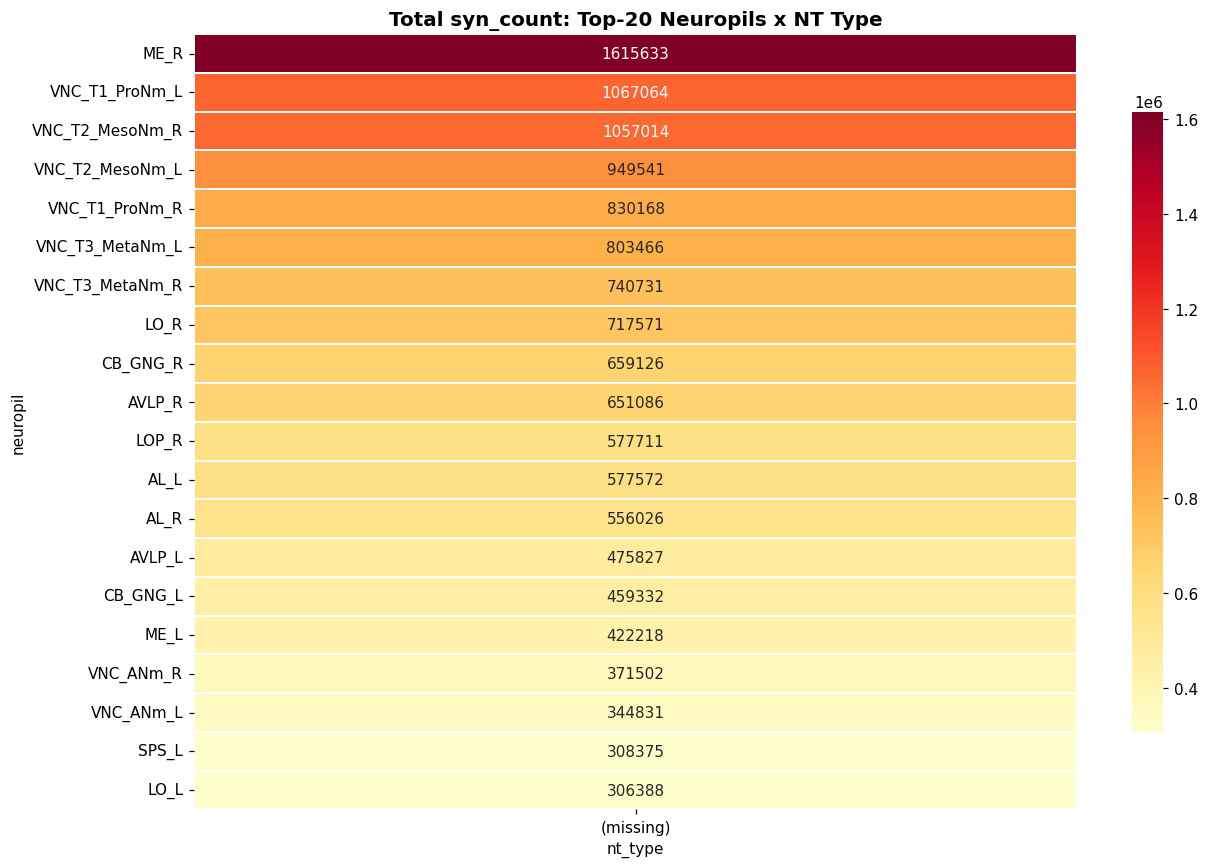

In [2]:
pivot = syn_count_per_neuropil_nt(conn_df)
top20 = pivot.sum(axis=1).nlargest(20).index
plot_heatmap(pivot.loc[top20],
             title='Total syn_count: Top-20 Neuropils x NT Type',
             figsize=(12, 8))
plt.show()

## 8. Per-Neuropil Total Synapse Count (Top 20)

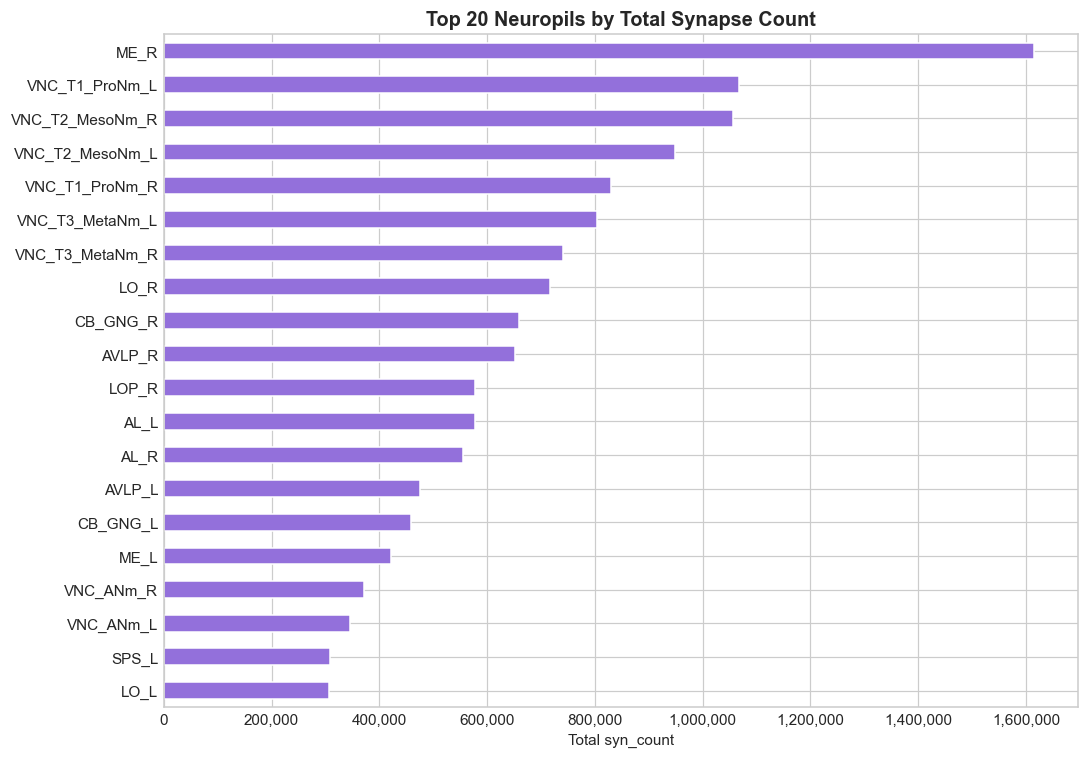

In [3]:
syn_by_neuropil = (
    conn_df.groupby('neuropil')['syn_count']
    .sum().sort_values(ascending=False).head(20)
)
plot_barh(syn_by_neuropil,
          title='Top 20 Neuropils by Total Synapse Count',
          xlabel='Total syn_count', color='mediumpurple', figsize=(10, 7))
plt.show()